# Purificação Simplificada — Simulação

Este notebook demonstra o módulo de purificação implementado na camada de enlace (LinkLayer) do QuantumNet.

**Componentes demonstrados:**
1. **Motor Probabilístico de Erro de Canal** — Cálculo de probabilidade de sucesso e nova fidelidade para diferentes tipos de ruído.
2. **Estratégia Simétrica** — Purificação em árvore ($2^r$ pares iniciais).
3. **Estratégia Pumping** — Purificação linear (par principal + pares frescos).
4. **Agendador Híbrido** — Pool de backup para recuperação de falhas.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from quantumnet.runtime import Clock
from quantumnet.topology.network import Network
from quantumnet.utils import MetricsCollector

## 1. Motor Probabilístico de Erro de Canal (RF1)

Comparando as fórmulas de bit-flip e Werner para diferentes fidelidades de entrada.

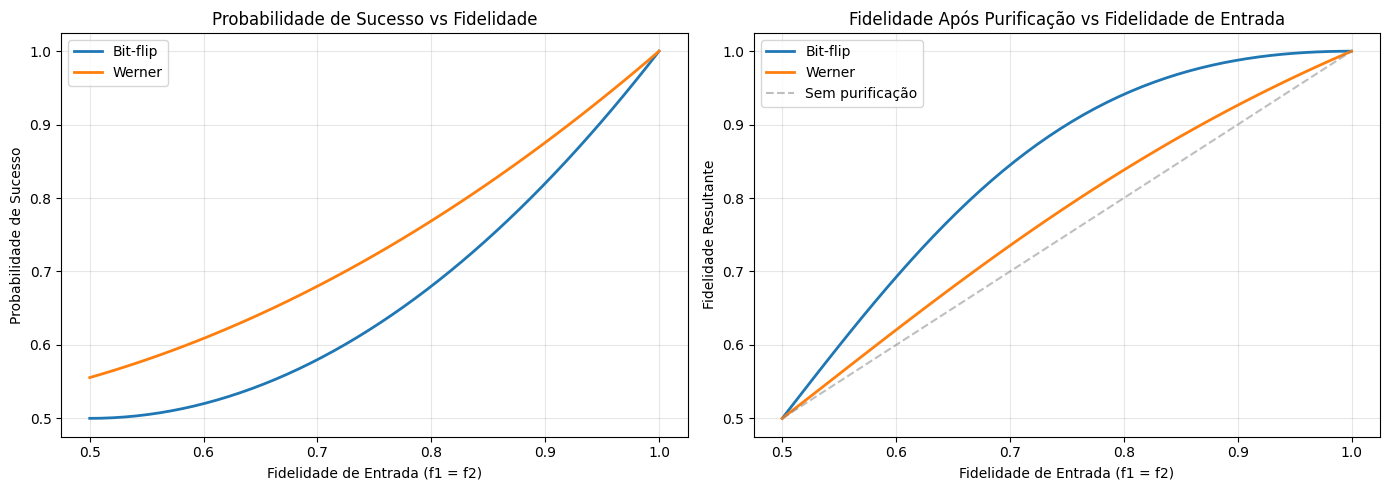

In [2]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 2)
ll = net.linklayer

fidelities = np.linspace(0.5, 1.0, 50)

bf_p, bf_f = [], []
w_p, w_f = [], []

for fid in fidelities:
    p, f = ll.channel_error_engine(fid, fid, 'bit-flip')
    bf_p.append(p)
    bf_f.append(f)
    
    p, f = ll.channel_error_engine(fid, fid, 'werner')
    w_p.append(p)
    w_f.append(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fidelities, bf_p, label='Bit-flip', linewidth=2)
axes[0].plot(fidelities, w_p, label='Werner', linewidth=2)
axes[0].set_xlabel('Fidelidade de Entrada (f1 = f2)')
axes[0].set_ylabel('Probabilidade de Sucesso')
axes[0].set_title('Probabilidade de Sucesso vs Fidelidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fidelities, bf_f, label='Bit-flip', linewidth=2)
axes[1].plot(fidelities, w_f, label='Werner', linewidth=2)
axes[1].plot(fidelities, fidelities, '--', color='gray', alpha=0.5, label='Sem purificação')
axes[1].set_xlabel('Fidelidade de Entrada (f1 = f2)')
axes[1].set_ylabel('Fidelidade Resultante')
axes[1].set_title('Fidelidade Após Purificação vs Fidelidade de Entrada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('purification_engine.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Comparação: Estratégia Simétrica vs Pumping (RF2)

Executamos ambas as estratégias com diferentes números de rounds e comparamos a fidelidade final obtida.

In [3]:
random.seed(42)

rounds_range = range(1, 5)
num_trials = 50  # Repetições para média estatística

sym_results = {r: [] for r in rounds_range}
pump_results = {r: [] for r in rounds_range}
sym_successes = {r: 0 for r in rounds_range}
pump_successes = {r: 0 for r in rounds_range}

for num_rounds in rounds_range:
    for trial in range(num_trials):
        # Simétrica
        clk = Clock()
        n = Network(clock=clk)
        n.config.defaults.eprs_per_channel = 50
        n.config.decoherence.per_timeslot = 0.98
        n.set_ready_topology('Line', 2)
        
        result = {}
        def cb_sym(success, epr=None, r=result):
            r['success'] = success
            r['fidelity'] = epr.current_fidelity if epr else None
        
        n.linklayer.run_purification(
            0, 1, strategy='symmetric', num_rounds=num_rounds,
            pool_size=4, on_complete=cb_sym)
        clk.run()
        
        if result.get('success'):
            sym_results[num_rounds].append(result['fidelity'])
            sym_successes[num_rounds] += 1
        
        # Pumping
        clk2 = Clock()
        n2 = Network(clock=clk2)
        n2.config.defaults.eprs_per_channel = 50
        n2.config.decoherence.per_timeslot = 0.98
        n2.set_ready_topology('Line', 2)
        
        result2 = {}
        def cb_pump(success, epr=None, r=result2):
            r['success'] = success
            r['fidelity'] = epr.current_fidelity if epr else None
        
        n2.linklayer.run_purification(
            0, 1, strategy='pumping', num_rounds=num_rounds,
            pool_size=4, on_complete=cb_pump)
        clk2.run()
        
        if result2.get('success'):
            pump_results[num_rounds].append(result2['fidelity'])
            pump_successes[num_rounds] += 1

print(f"{'Rounds':>6} | {'Simétrica (média)':>20} | {'Pumping (média)':>18} | {'Simétrica (sucesso %)':>22} | {'Pumping (sucesso %)':>20}")
print('-' * 95)
for r in rounds_range:
    s_avg = np.mean(sym_results[r]) if sym_results[r] else 0
    p_avg = np.mean(pump_results[r]) if pump_results[r] else 0
    s_rate = 100 * sym_successes[r] / num_trials
    p_rate = 100 * pump_successes[r] / num_trials
    print(f"{r:>6} | {s_avg:>20.6f} | {p_avg:>18.6f} | {s_rate:>21.1f}% | {p_rate:>19.1f}%")

Rounds |    Simétrica (média) |    Pumping (média) |  Simétrica (sucesso %) |  Pumping (sucesso %)
-----------------------------------------------------------------------------------------------
     1 |             0.999584 |           0.999584 |                 100.0% |               100.0%
     2 |             0.999568 |           0.999575 |                 100.0% |               100.0%
     3 |             0.999567 |           0.999575 |                  98.0% |               100.0%
     4 |             0.999567 |           0.999575 |                  98.0% |               100.0%


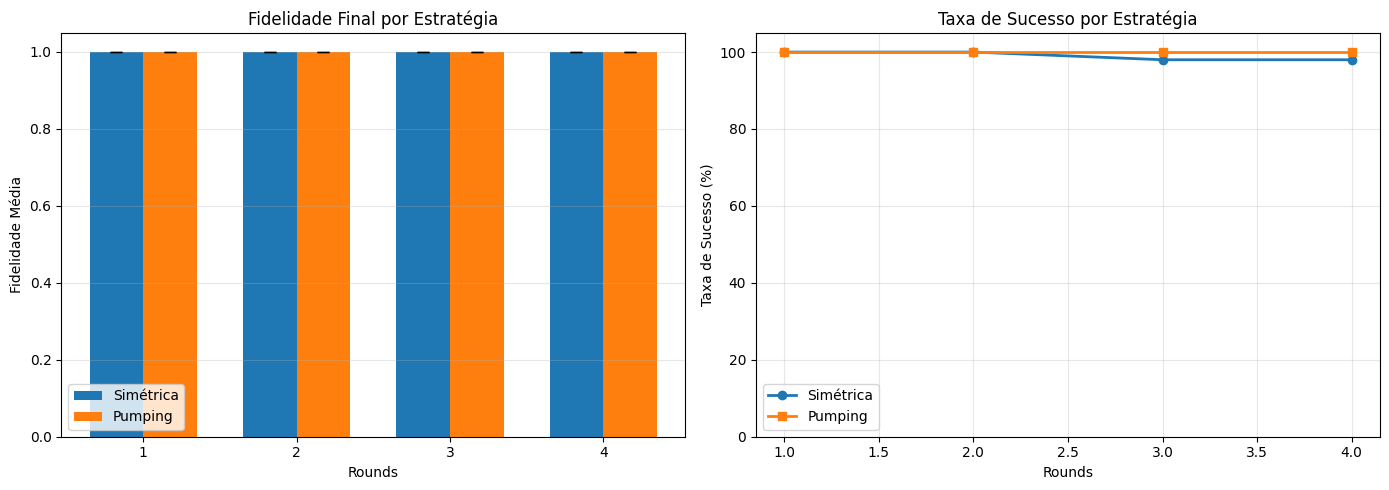

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rounds_list = list(rounds_range)
sym_avgs = [np.mean(sym_results[r]) if sym_results[r] else 0 for r in rounds_list]
pump_avgs = [np.mean(pump_results[r]) if pump_results[r] else 0 for r in rounds_list]
sym_stds = [np.std(sym_results[r]) if sym_results[r] else 0 for r in rounds_list]
pump_stds = [np.std(pump_results[r]) if pump_results[r] else 0 for r in rounds_list]

x = np.arange(len(rounds_list))
width = 0.35

axes[0].bar(x - width/2, sym_avgs, width, yerr=sym_stds, label='Simétrica', capsize=4)
axes[0].bar(x + width/2, pump_avgs, width, yerr=pump_stds, label='Pumping', capsize=4)
axes[0].set_xlabel('Rounds')
axes[0].set_ylabel('Fidelidade Média')
axes[0].set_title('Fidelidade Final por Estratégia')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rounds_list)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

sym_rates = [100 * sym_successes[r] / num_trials for r in rounds_list]
pump_rates = [100 * pump_successes[r] / num_trials for r in rounds_list]

axes[1].plot(rounds_list, sym_rates, 'o-', linewidth=2, label='Simétrica')
axes[1].plot(rounds_list, pump_rates, 's-', linewidth=2, label='Pumping')
axes[1].set_xlabel('Rounds')
axes[1].set_ylabel('Taxa de Sucesso (%)')
axes[1].set_title('Taxa de Sucesso por Estratégia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('purification_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Impacto do Ruído de Canal (RF1)

Comparando a fidelidade final obtida pela estratégia simétrica sob diferentes tipos de ruído.

C:\Users\artue\AppData\Local\Temp\ipykernel_4940\3884174069.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True)


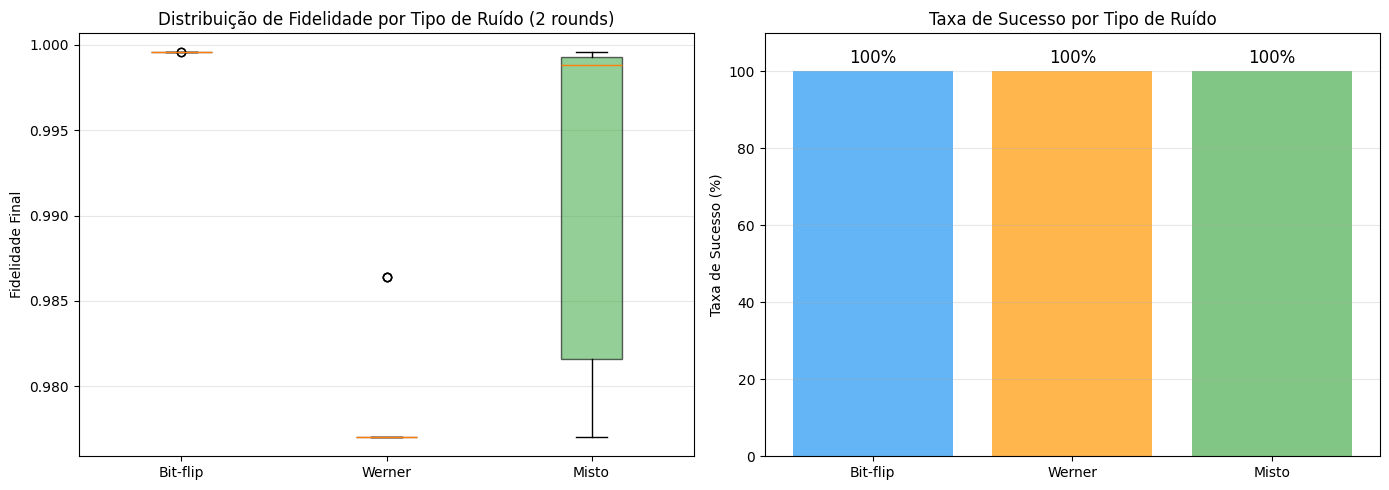

In [5]:
random.seed(7)

noise_types = ['bit-flip', 'werner', 'bitflip+werner']
num_trials = 100
num_rounds = 2

noise_results = {nt: [] for nt in noise_types}
noise_successes = {nt: 0 for nt in noise_types}

for nt in noise_types:
    for trial in range(num_trials):
        clk = Clock()
        n = Network(clock=clk)
        n.config.defaults.channel_noise_type = nt
        n.config.defaults.eprs_per_channel = 20
        n.config.decoherence.per_timeslot = 0.98
        n.set_ready_topology('Line', 2)
        
        result = {}
        def cb(success, epr=None, r=result):
            r['success'] = success
            r['fidelity'] = epr.current_fidelity if epr else None
        
        n.linklayer.run_purification(
            0, 1, strategy='symmetric', num_rounds=num_rounds,
            pool_size=4, on_complete=cb)
        clk.run()
        
        if result.get('success'):
            noise_results[nt].append(result['fidelity'])
            noise_successes[nt] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot das fidelidades
data = [noise_results[nt] for nt in noise_types]
labels = ['Bit-flip', 'Werner', 'Misto']
bp = axes[0].boxplot(data, labels=labels, patch_artist=True)
colors = ['#2196F3', '#FF9800', '#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel('Fidelidade Final')
axes[0].set_title(f'Distribuição de Fidelidade por Tipo de Ruído ({num_rounds} rounds)')
axes[0].grid(True, alpha=0.3, axis='y')

# Taxa de sucesso
rates = [100 * noise_successes[nt] / num_trials for nt in noise_types]
bars = axes[1].bar(labels, rates, color=colors, alpha=0.7)
for bar, rate in zip(bars, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{rate:.0f}%', ha='center', va='bottom', fontsize=12)
axes[1].set_ylabel('Taxa de Sucesso (%)')
axes[1].set_title('Taxa de Sucesso por Tipo de Ruído')
axes[1].set_ylim(0, 110)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('purification_noise_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pool de Backup — Agendador Híbrido (RF3)

Verificamos como o tamanho do pool de backup impacta a taxa de sucesso da purificação,
especialmente quando os EPRs iniciais têm fidelidades menores.

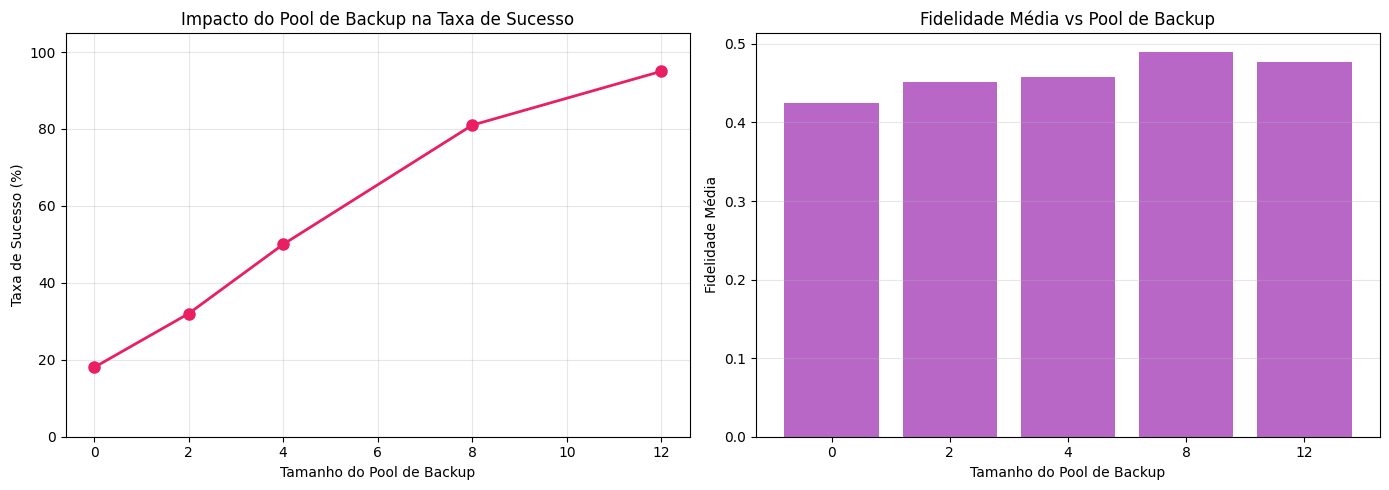

In [6]:
random.seed(99)

pool_sizes = [0, 2, 4, 8, 12]
num_trials = 100
num_rounds = 2

pool_results = {ps: {'success': 0, 'fids': []} for ps in pool_sizes}

for ps in pool_sizes:
    for trial in range(num_trials):
        clk = Clock()
        n = Network(clock=clk)
        n.config.defaults.eprs_per_channel = 30
        n.config.decoherence.per_timeslot = 0.85  # Decoerência agressiva
        n.set_ready_topology('Line', 2)
        
        # Avançar o clock para degradar os EPRs
        clk.schedule(3, lambda: None)
        clk.step()
        
        result = {}
        def cb(success, epr=None, r=result):
            r['success'] = success
            r['fidelity'] = epr.current_fidelity if epr else None
        
        n.linklayer.run_purification(
            0, 1, strategy='symmetric', num_rounds=num_rounds,
            pool_size=ps, on_complete=cb)
        clk.run()
        
        if result.get('success'):
            pool_results[ps]['success'] += 1
            pool_results[ps]['fids'].append(result['fidelity'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates = [100 * pool_results[ps]['success'] / num_trials for ps in pool_sizes]
axes[0].plot(pool_sizes, rates, 'o-', linewidth=2, markersize=8, color='#E91E63')
axes[0].set_xlabel('Tamanho do Pool de Backup')
axes[0].set_ylabel('Taxa de Sucesso (%)')
axes[0].set_title('Impacto do Pool de Backup na Taxa de Sucesso')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 105)

avg_fids = [np.mean(pool_results[ps]['fids']) if pool_results[ps]['fids'] else 0 for ps in pool_sizes]
axes[1].bar(range(len(pool_sizes)), avg_fids, tick_label=[str(ps) for ps in pool_sizes],
            color='#9C27B0', alpha=0.7)
axes[1].set_xlabel('Tamanho do Pool de Backup')
axes[1].set_ylabel('Fidelidade Média')
axes[1].set_title('Fidelidade Média vs Pool de Backup')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('purification_pool_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Simulação Completa com MetricsCollector

Execução completa com coleta de métricas em CSV, demonstrando a integração
do módulo de purificação com o sistema de eventos do QuantumNet.

In [7]:
random.seed(2026)

clock = Clock()
net = Network(clock=clock)
net.config.defaults.eprs_per_channel = 30
net.config.defaults.channel_noise_type = 'bit-flip'
net.config.decoherence.per_timeslot = 0.95

with MetricsCollector(clock, 'purification_metrics.csv') as col:
    net.set_ready_topology('Line', 4)
    
    outcomes = []
    
    # Canal 0-1: Simétrica com 2 rounds
    def on_01(success, epr=None):
        outcomes.append(('0-1 symmetric', success, epr.current_fidelity if epr else None))
    net.linklayer.run_purification(0, 1, strategy='symmetric', num_rounds=2, pool_size=4, on_complete=on_01)
    
    # Canal 1-2: Pumping com 3 rounds, ruído Werner
    net.graph.edges[1, 2]['noise_type'] = 'werner'
    def on_12(success, epr=None):
        outcomes.append(('1-2 pumping', success, epr.current_fidelity if epr else None))
    net.linklayer.run_purification(1, 2, strategy='pumping', num_rounds=3, pool_size=2, on_complete=on_12)
    
    # Canal 2-3: Simétrica com ruído misto
    net.graph.edges[2, 3]['noise_type'] = 'bitflip+werner'
    def on_23(success, epr=None):
        outcomes.append(('2-3 symmetric mixed', success, epr.current_fidelity if epr else None))
    net.linklayer.run_purification(2, 3, strategy='symmetric', num_rounds=2, pool_size=6, on_complete=on_23)
    
    clock.run()

print('=== Resultados da Simulação ===')
print(f'{"Canal":>25} | {"Sucesso":>8} | {"Fidelidade":>12}')
print('-' * 52)
for name, success, fid in outcomes:
    fid_str = f'{fid:.6f}' if fid else 'N/A'
    print(f'{name:>25} | {str(success):>8} | {fid_str:>12}')

=== Resultados da Simulação ===
                    Canal |  Sucesso |   Fidelidade
----------------------------------------------------
            0-1 symmetric |     True |     0.996924
              1-2 pumping |     True |     0.947838
      2-3 symmetric mixed |     True |     0.994979


In [8]:
# Carregar e exibir métricas coletadas
df = pd.read_csv('purification_metrics.csv')

# Filtrar eventos de purificação
purif_events = df[df['event_type'].str.contains('purif', case=False)]
print(f'Total de eventos de purificação: {len(purif_events)}')
print()
print(purif_events[['clock_tick', 'event_type', 'source_node', 'target_node', 'value']].to_string(index=False))

Total de eventos de purificação: 18

 clock_tick                 event_type  source_node  target_node    value
          0   purification_provisioned          0.0          1.0      NaN
          0   purification_provisioned          1.0          2.0      NaN
          0   purification_provisioned          2.0          3.0      NaN
          1       purification_started          0.0          1.0      NaN
          1 purification_round_success          0.0          1.0 0.997238
          1 purification_round_success          0.0          1.0 0.997238
          1 purification_round_success          0.0          1.0 0.996924
          1       purification_success          0.0          1.0 0.996924
          1       purification_started          1.0          2.0      NaN
          1 purification_round_success          1.0          2.0 0.964964
          1 purification_round_success          1.0          2.0 0.952448
          1 purification_round_success          1.0          2.0 0.947838
 

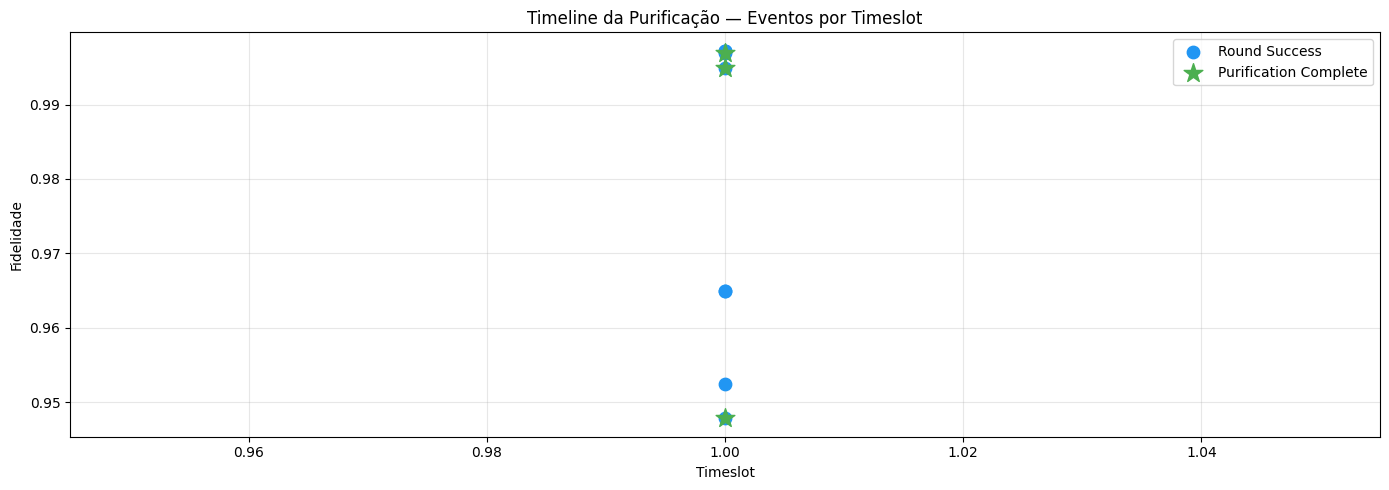

In [9]:
# Visualizar timeline dos eventos de purificação
round_success = purif_events[purif_events['event_type'] == 'purification_round_success'].copy()
pool_recovery = purif_events[purif_events['event_type'] == 'purification_pool_recovery'].copy()
final_success = purif_events[purif_events['event_type'] == 'purification_success'].copy()

fig, ax = plt.subplots(figsize=(14, 5))

if not round_success.empty:
    ax.scatter(round_success['clock_tick'], round_success['value'],
               marker='o', s=80, label='Round Success', color='#2196F3', zorder=3)
if not pool_recovery.empty:
    ax.scatter(pool_recovery['clock_tick'], pool_recovery['value'],
               marker='^', s=100, label='Pool Recovery', color='#FF9800', zorder=3)
if not final_success.empty:
    ax.scatter(final_success['clock_tick'], final_success['value'],
               marker='*', s=200, label='Purification Complete', color='#4CAF50', zorder=4)

ax.set_xlabel('Timeslot')
ax.set_ylabel('Fidelidade')
ax.set_title('Timeline da Purificação — Eventos por Timeslot')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('purification_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Decoerência entre Rounds

Demonstrando como a taxa de decoerência impacta a qualidade da purificação.
Pares ociosos entre rounds sofrem degradação (RF2.3).

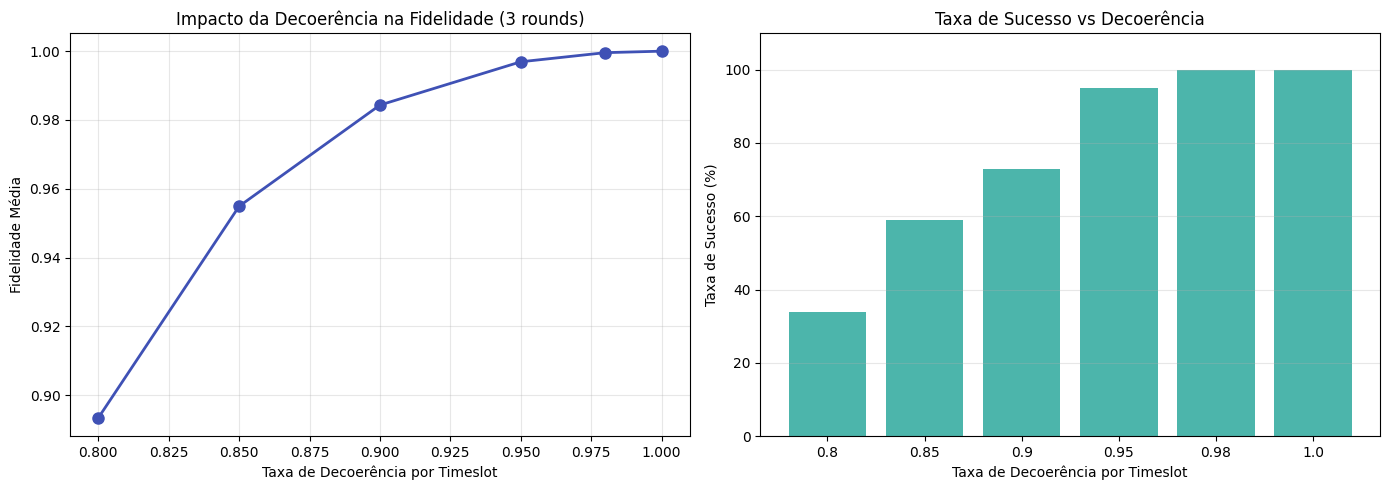

 Decoerência |   Fidelidade Média |  Sucesso (%)
--------------------------------------------------
        0.80 |           0.893416 |        34.0%
        0.85 |           0.954925 |        59.0%
        0.90 |           0.984339 |        73.0%
        0.95 |           0.996915 |        95.0%
        0.98 |           0.999566 |       100.0%
        1.00 |           1.000000 |       100.0%


In [10]:
random.seed(42)

decoherence_rates = [0.80, 0.85, 0.90, 0.95, 0.98, 1.0]
num_trials = 100
num_rounds = 3

dec_results = {dr: {'fids': [], 'success': 0} for dr in decoherence_rates}

for dr in decoherence_rates:
    for _ in range(num_trials):
        clk = Clock()
        n = Network(clock=clk)
        n.config.defaults.eprs_per_channel = 30
        n.config.decoherence.per_timeslot = dr
        n.set_ready_topology('Line', 2)
        
        result = {}
        def cb(success, epr=None, r=result):
            r['success'] = success
            r['fidelity'] = epr.current_fidelity if epr else None
        
        n.linklayer.run_purification(
            0, 1, strategy='symmetric', num_rounds=num_rounds,
            pool_size=4, on_complete=cb)
        clk.run()
        
        if result.get('success'):
            dec_results[dr]['fids'].append(result['fidelity'])
            dec_results[dr]['success'] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dr_labels = [str(dr) for dr in decoherence_rates]
avg_fids = [np.mean(dec_results[dr]['fids']) if dec_results[dr]['fids'] else 0 for dr in decoherence_rates]
success_rates = [100 * dec_results[dr]['success'] / num_trials for dr in decoherence_rates]

axes[0].plot(decoherence_rates, avg_fids, 'o-', linewidth=2, markersize=8, color='#3F51B5')
axes[0].set_xlabel('Taxa de Decoerência por Timeslot')
axes[0].set_ylabel('Fidelidade Média')
axes[0].set_title(f'Impacto da Decoerência na Fidelidade ({num_rounds} rounds)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(dr_labels, success_rates, color='#009688', alpha=0.7)
axes[1].set_xlabel('Taxa de Decoerência por Timeslot')
axes[1].set_ylabel('Taxa de Sucesso (%)')
axes[1].set_title('Taxa de Sucesso vs Decoerência')
axes[1].set_ylim(0, 110)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('purification_decoherence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Decoerência':>12} | {'Fidelidade Média':>18} | {'Sucesso (%)':>12}")
print('-' * 50)
for dr in decoherence_rates:
    avg = np.mean(dec_results[dr]['fids']) if dec_results[dr]['fids'] else 0
    rate = 100 * dec_results[dr]['success'] / num_trials
    print(f"{dr:>12.2f} | {avg:>18.6f} | {rate:>11.1f}%")